<a href="https://colab.research.google.com/github/Harshithpalan/yfinance/blob/main/yfinance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = yf.download('AAPL', start='2022-01-01', end='2024-01-01')

In [ ]:
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

In [ ]:
X = df[['Open', 'High', 'Low', 'Close', 'Volume']]
y = df['Target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [ ]:
print("Linear Regression:")
print("  MSE:", mean_squared_error(y_test, lr_pred))
print("  R2:", r2_score(y_test, lr_pred))
print("\nRandom Forest:")
print("  MSE:", mean_squared_error(y_test, rf_pred))
print("  R2:", r2_score(y_test, rf_pred))

Linear Regression:
  MSE: 9.014220598248023
  R2: 0.9665985241892635

Random Forest:
  MSE: 10.434226562738361
  R2: 0.961336805291099


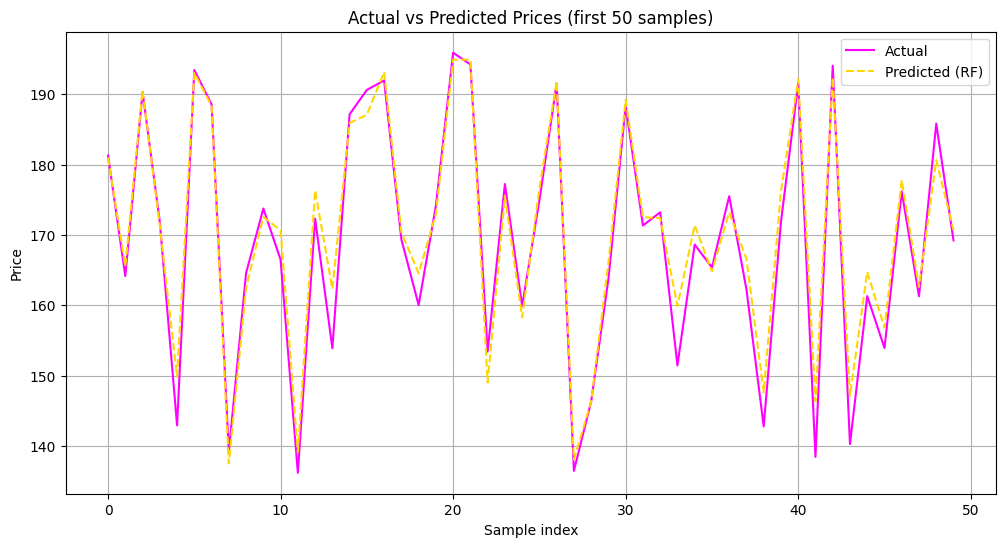

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label='Actual', color='magenta', linestyle='-')
plt.plot(rf_pred[:50], label='Predicted (RF)', color='gold', linestyle='--')
plt.title('Actual vs Predicted Prices (first 50 samples)')
plt.xlabel('Sample index')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
importances = rf.feature_importances_
features = X.columns
feature_df = pd.DataFrame({
'Feature': features,
'Importance': importances
})

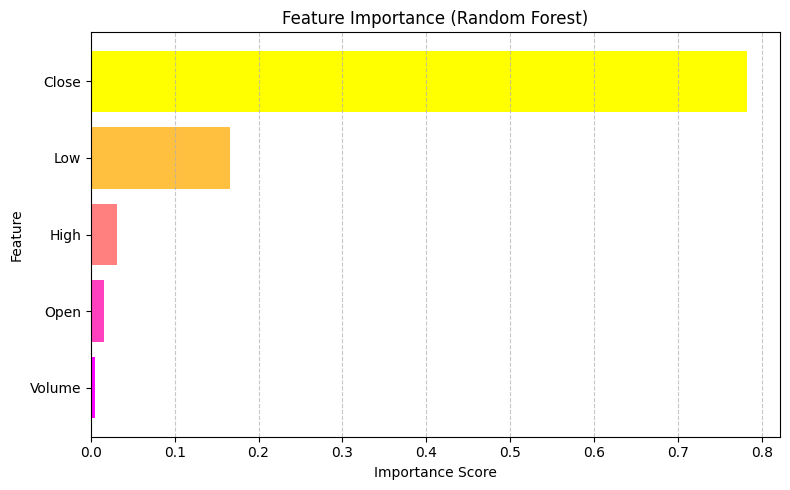

In [ ]:
feature_df = feature_df.sort_values(by='Importance', ascending=True)
feature_df['Feature'] = feature_df['Feature'].apply(lambda x: x[0])
colors = plt.cm.spring(np.linspace(0, 1, len(feature_df)))
plt.figure(figsize=(8, 5))
plt.barh(feature_df['Feature'], feature_df['Importance'], color=colors)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Feature Importance (Random Forest)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()